<a href="https://colab.research.google.com/github/m4tt-nm/martino_DSPN_S26/blob/master/ExerciseSubmissions/16_selecting-the-best-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 16: Model selection

This homework is designed to give you practice implementing model selection techniques, including best subset selection and forward/backward stepwise selection.

You won't need to load in any data for this homework, we will be simulating our own.

---
## 1. Best subset selection (4 points)

In this question, we will first generate simulated data, and then use it to perform best subset selection.

a) Use `rnorm()` to generate a dataset including a predictor $X$ of length $n = 100$ and a noise vector $\epsilon$ of length $n = 100$. Generate data for a response variable $Y$ of length $n = 100$ according to the model

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [1]:
# WRITE YOUR CODE HERE
set.seed(15)
x <- rnorm(100)
epsilon <- rnorm(100)
beta_0 <- 2
beta_1 <- 10
beta_2 <- 0.1
beta_3 <- 0.5

y <- beta_0 + beta_1*x + beta_2*(x^2) + beta_3*(x^3) + epsilon

dat <- data.frame(x=x, epsilon=epsilon, y=y)
head(dat)

,x,epsilon,y
,<dbl>,<dbl>,<dbl>
1,0.2588229,-0.04002574,4.563571
2,1.8311207,-0.02965667,23.686727
3,-0.3396186,-1.20807993,-2.612317
4,0.8971982,1.46533851,12.878923
5,0.4880163,1.07910868,8.041200
6,-1.2553858,-0.33477338,-11.720272


b) Use `regsubsets()` to perform best subset selection to determine the best model that contains the predictor variables $X$, $X^2$, . . . , $X^{10}$. Print the model summary.

In [2]:
# WRITE YOUR CODE HERE
install.packages("tidyverse")
install.packages("leaps")
library(tidyverse)
library(leaps)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [4]:
regfit.full <- regsubsets(y ~ poly(x, 10, raw = TRUE), data = dat, nvmax = 10)
reg.summary <- summary(regfit.full)
reg.summary

Subset selection object
Call: regsubsets.formula(y ~ poly(x, 10, raw = TRUE), data = dat, nvmax = 10)
10 Variables  (and intercept)
                          Forced in Forced out
poly(x, 10, raw = TRUE)1      FALSE      FALSE
poly(x, 10, raw = TRUE)2      FALSE      FALSE
poly(x, 10, raw = TRUE)3      FALSE      FALSE
poly(x, 10, raw = TRUE)4      FALSE      FALSE
poly(x, 10, raw = TRUE)5      FALSE      FALSE
poly(x, 10, raw = TRUE)6      FALSE      FALSE
poly(x, 10, raw = TRUE)7      FALSE      FALSE
poly(x, 10, raw = TRUE)8      FALSE      FALSE
poly(x, 10, raw = TRUE)9      FALSE      FALSE
poly(x, 10, raw = TRUE)10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: exhaustive
          poly(x, 10, raw = TRUE)1 poly(x, 10, raw = TRUE)2
1  ( 1 )  "*"                      " "                     
2  ( 1 )  "*"                      " "                     
3  ( 1 )  "*"                      "*"                     
4  ( 1 )  "*"                      "*"         

In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```


```

c) Plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Based on each criterion, identify the best model size. Report the coefficients of the best model.

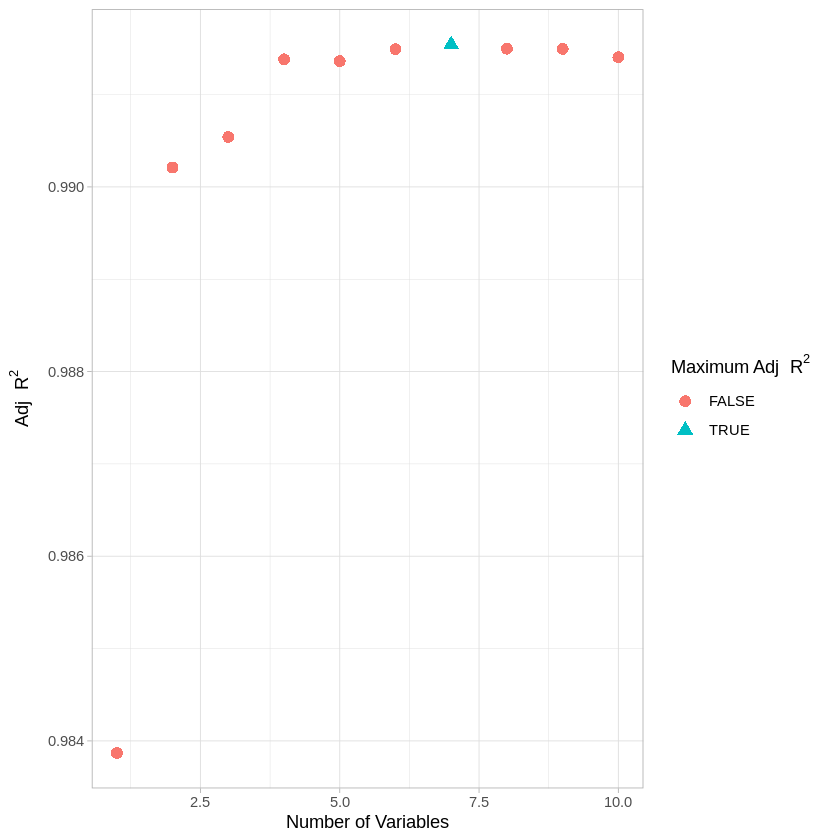

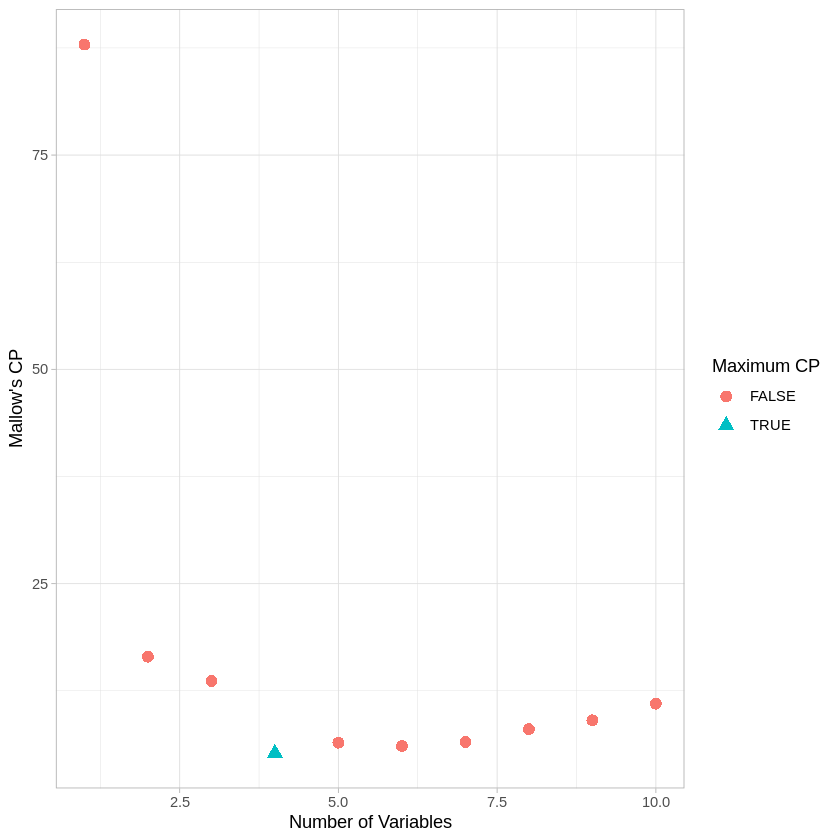

[1] 7

[1] 4

[1] 4

(Intercept) poly(x, 10, raw = TRUE)1 poly(x, 10, raw = TRUE)2 
              1.56961161              10.03196689               0.60086631 
poly(x, 10, raw = TRUE)3 poly(x, 10, raw = TRUE)6 
              0.49080549              -0.01730072

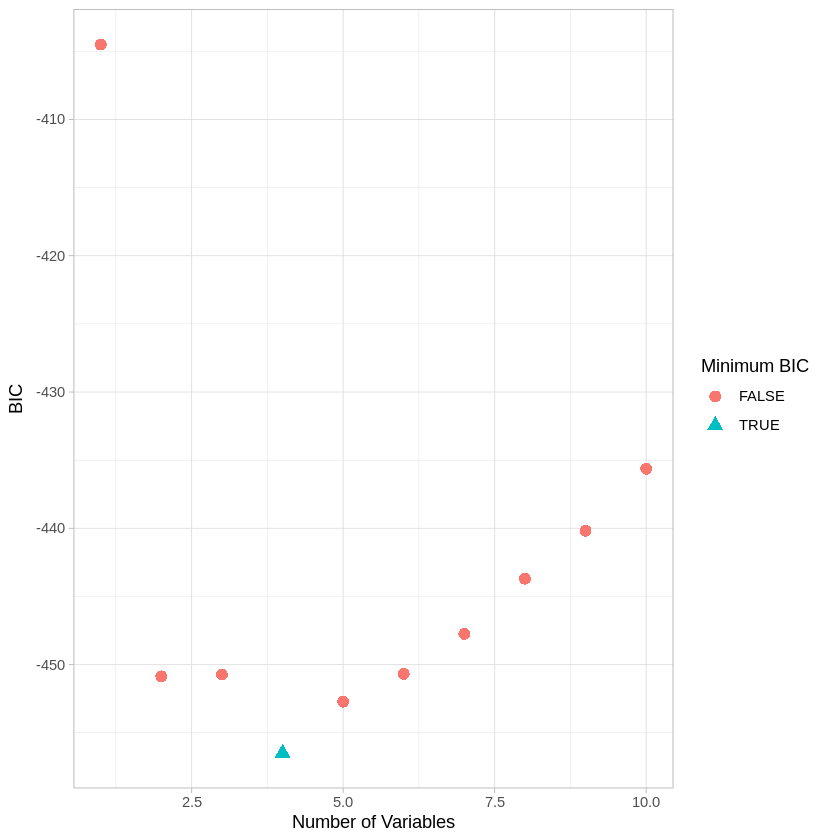

In [7]:
# WRITE YOUR CODE HERE
numvar = 1:length(reg.summary$rss)
allfalse = rep(FALSE,length(reg.summary$rss))

adjr2.df <- data.frame(numvar = numvar, adjr2 = reg.summary$adjr2, maxadjr2 = allfalse)
adjr2.df$maxadjr2[which.max(reg.summary$adjr2)] <- TRUE
ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = expression('Adj'~R^2), color=expression('Maximum Adj'~R^2), shape=expression('Maximum Adj'~R^2))

cp.df <- data.frame(numvar = numvar, cp = reg.summary$cp, mincp = allfalse)
cp.df$mincp[which.min(reg.summary$cp)] <- TRUE
ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")

bic.df <- data.frame(numvar = numvar,bic = reg.summary$bic, minbic = allfalse)
bic.df$minbic[which.min(reg.summary$bic)] <- TRUE
ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")


which.max(reg.summary$adjr2)
which.min(reg.summary$cp)
which.min(reg.summary$bic)
coef(regfit.full, which.min(reg.summary$bic))

> The best model size according to R^2 is 7 variables, but for Mallow's CP and BIC it's 4 variables. I chose 4 variables as the best size considering all outputs, and the coefs of the 4 variable model are x^1, x^2, x^3, and x^6.
>

---
## 2. Forward and backwards stepwise selection (3 points)

Using the same simulated data from question 1, use forward stepwise selection, and backwards stepwise selections to identify the best model under each criterion. Again, for both model selection methods, plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Report the coefficients of the best model.

a) Forward stepwise selection:

Subset selection object
Call: regsubsets.formula(y ~ poly(x, 10, raw = TRUE), data = dat, nvmax = 10, 
    method = "forward")
10 Variables  (and intercept)
                          Forced in Forced out
poly(x, 10, raw = TRUE)1      FALSE      FALSE
poly(x, 10, raw = TRUE)2      FALSE      FALSE
poly(x, 10, raw = TRUE)3      FALSE      FALSE
poly(x, 10, raw = TRUE)4      FALSE      FALSE
poly(x, 10, raw = TRUE)5      FALSE      FALSE
poly(x, 10, raw = TRUE)6      FALSE      FALSE
poly(x, 10, raw = TRUE)7      FALSE      FALSE
poly(x, 10, raw = TRUE)8      FALSE      FALSE
poly(x, 10, raw = TRUE)9      FALSE      FALSE
poly(x, 10, raw = TRUE)10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: forward
          poly(x, 10, raw = TRUE)1 poly(x, 10, raw = TRUE)2
1  ( 1 )  "*"                      " "                     
2  ( 1 )  "*"                      " "                     
3  ( 1 )  "*"                      "*"                     
4  ( 1 )  "*"            

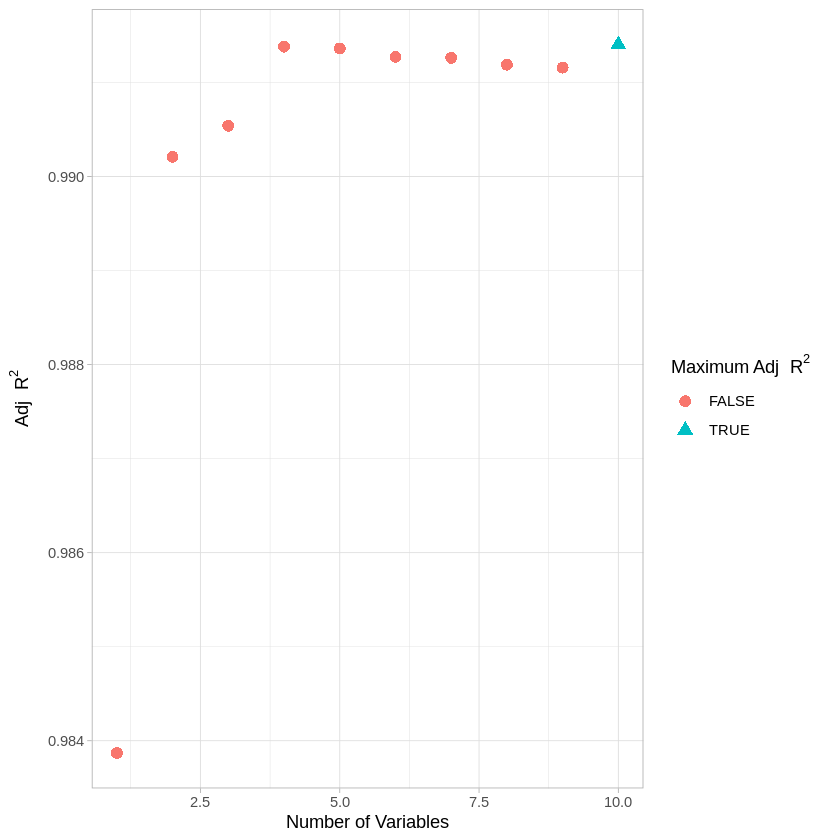

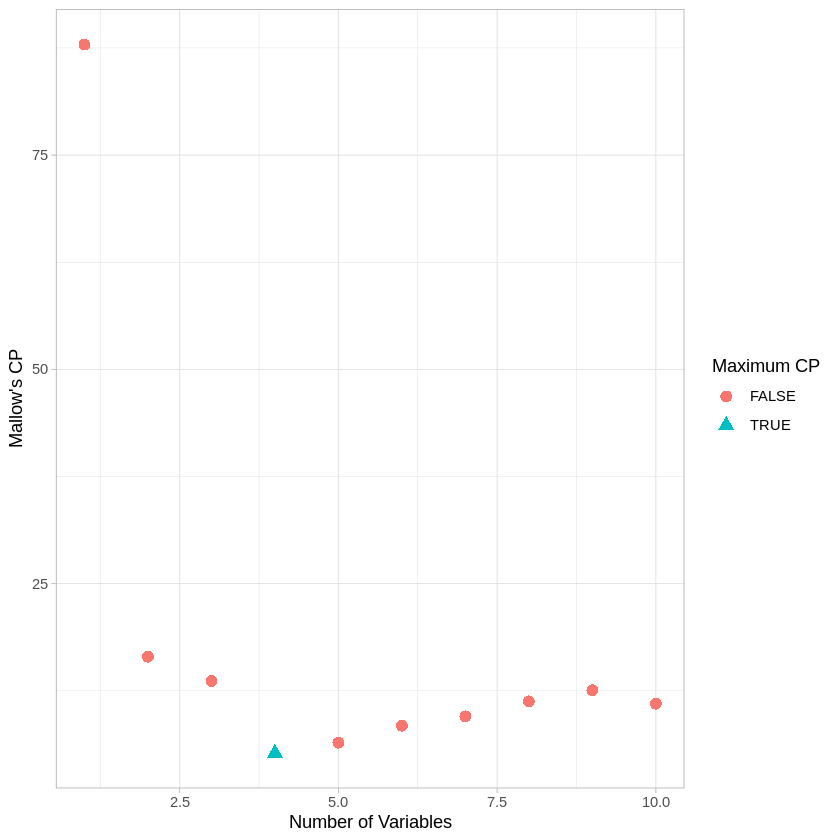

[1] 10

[1] 4

[1] 4

(Intercept) poly(x, 10, raw = TRUE)1 poly(x, 10, raw = TRUE)2 
              1.56961161              10.03196689               0.60086631 
poly(x, 10, raw = TRUE)3 poly(x, 10, raw = TRUE)6 
              0.49080549              -0.01730072

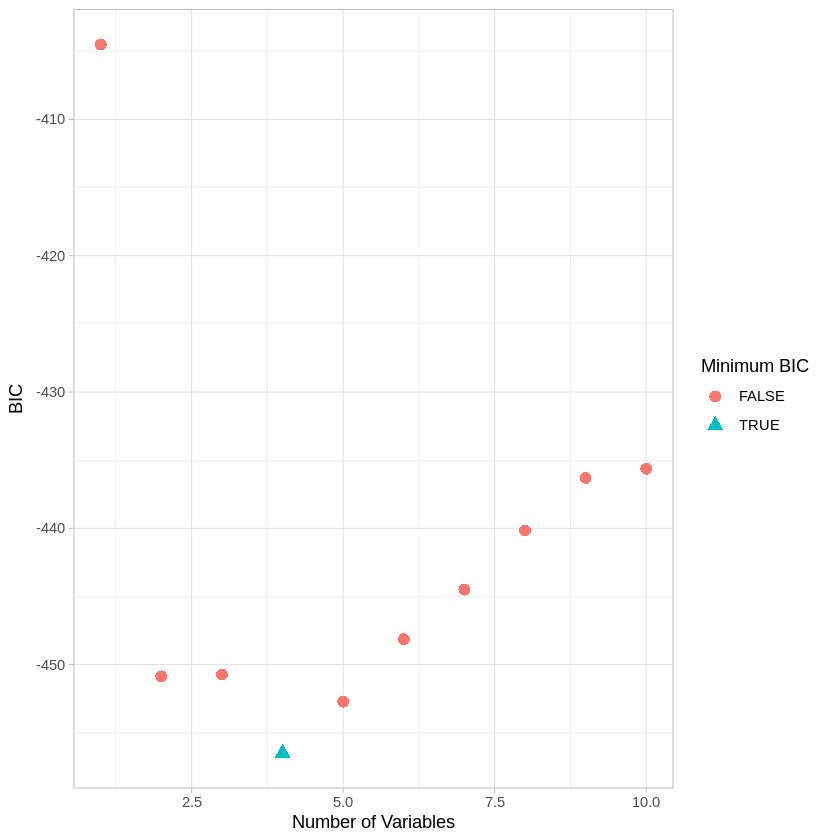

In [15]:
# WRITE YOUR CODE HERE
regfit.forward <- regsubsets(y ~ poly(x, 10, raw = TRUE), data = dat, nvmax = 10, method = "forward")
forward.summary <- summary(regfit.forward)
forward.summary

numvar = 1:length(forward.summary$rss)
allfalse = rep(FALSE,length(forward.summary$rss))

adjr2.df <- data.frame(numvar = numvar, adjr2 = forward.summary$adjr2, maxadjr2 = allfalse)
adjr2.df$maxadjr2[which.max(forward.summary$adjr2)] <- TRUE
ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = expression('Adj'~R^2), color=expression('Maximum Adj'~R^2), shape=expression('Maximum Adj'~R^2))

cp.df <- data.frame(numvar = numvar, cp = forward.summary$cp, mincp = allfalse)
cp.df$mincp[which.min(forward.summary$cp)] <- TRUE
ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")

bic.df <- data.frame(numvar = numvar,bic = forward.summary$bic, minbic = allfalse)
bic.df$minbic[which.min(forward.summary$bic)] <- TRUE
ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")


which.max(forward.summary$adjr2)
which.min(forward.summary$cp)
which.min(forward.summary$bic)
coef(regfit.forward, which.min(forward.summary$bic))



In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

b) Backwards stepwise selection:

Subset selection object
Call: regsubsets.formula(y ~ poly(x, 10, raw = TRUE), data = dat, nvmax = 10, 
    method = "backward")
10 Variables  (and intercept)
                          Forced in Forced out
poly(x, 10, raw = TRUE)1      FALSE      FALSE
poly(x, 10, raw = TRUE)2      FALSE      FALSE
poly(x, 10, raw = TRUE)3      FALSE      FALSE
poly(x, 10, raw = TRUE)4      FALSE      FALSE
poly(x, 10, raw = TRUE)5      FALSE      FALSE
poly(x, 10, raw = TRUE)6      FALSE      FALSE
poly(x, 10, raw = TRUE)7      FALSE      FALSE
poly(x, 10, raw = TRUE)8      FALSE      FALSE
poly(x, 10, raw = TRUE)9      FALSE      FALSE
poly(x, 10, raw = TRUE)10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: backward
          poly(x, 10, raw = TRUE)1 poly(x, 10, raw = TRUE)2
1  ( 1 )  "*"                      " "                     
2  ( 1 )  "*"                      " "                     
3  ( 1 )  "*"                      " "                     
4  ( 1 )  "*"          

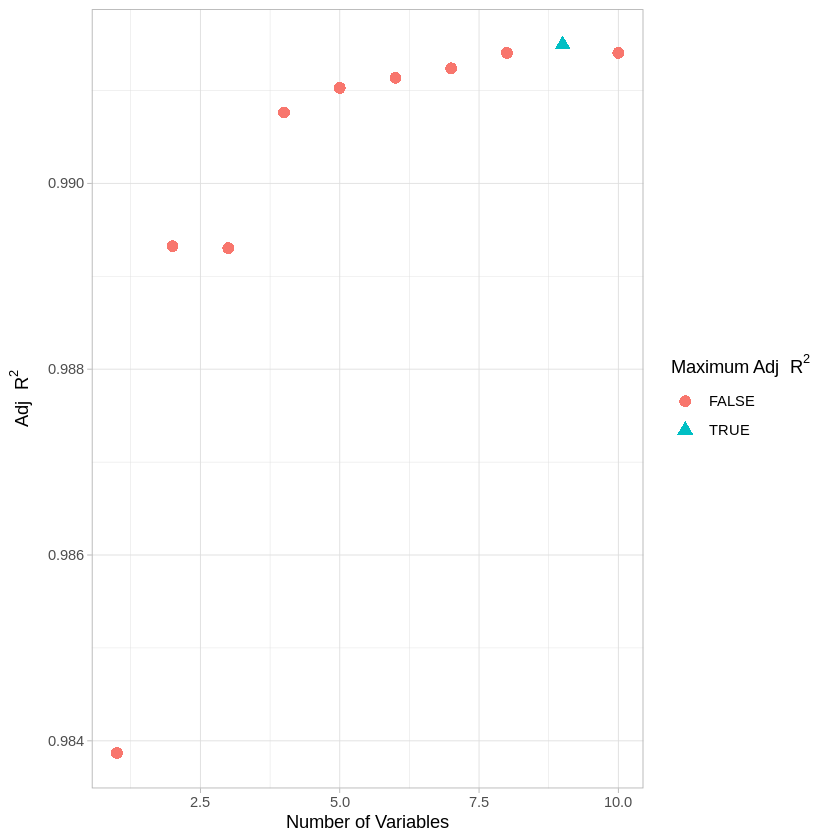

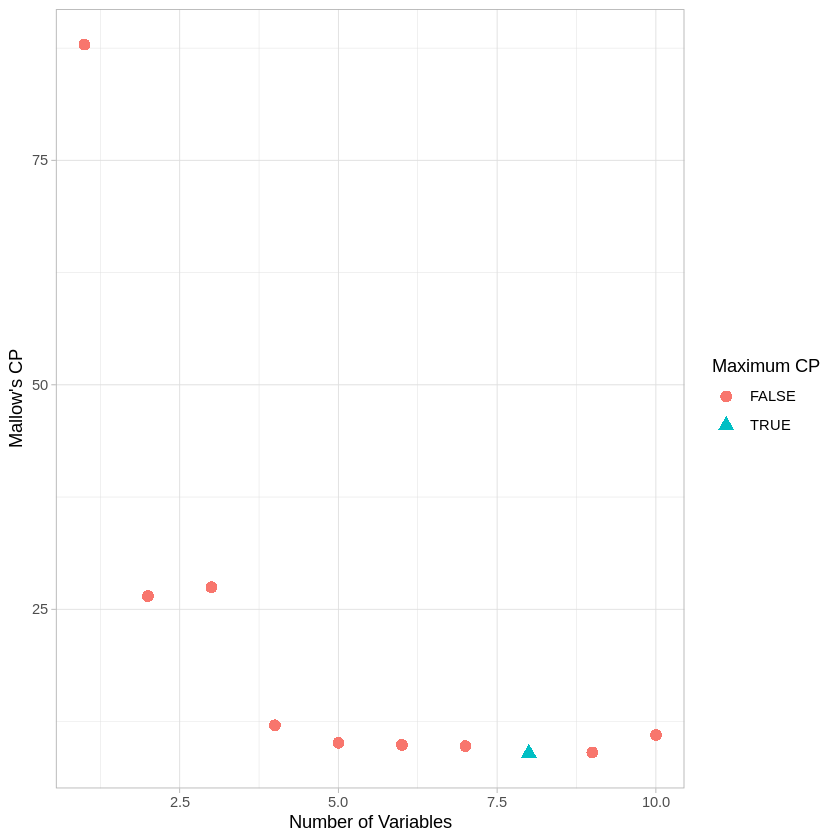

[1] 9

[1] 8

[1] 4

(Intercept) poly(x, 10, raw = TRUE)1 poly(x, 10, raw = TRUE)4 
              1.71877914              10.58661998               0.35278257 
poly(x, 10, raw = TRUE)5 poly(x, 10, raw = TRUE)6 
              0.06812132              -0.06077000

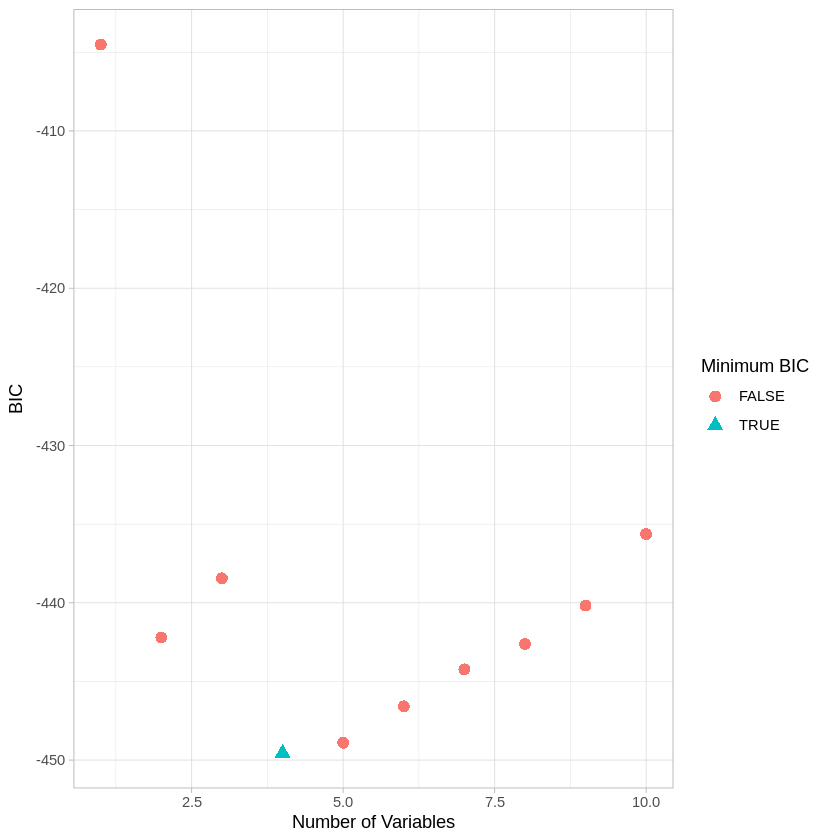

In [16]:
# WRITE YOUR CODE HERE
regfit.backward <- regsubsets(y ~ poly(x, 10, raw = TRUE), data = dat, nvmax = 10, method = "backward")
backward.summary <- summary(regfit.backward)
backward.summary

numvar = 1:length(backward.summary$rss)
allfalse = rep(FALSE,length(backward.summary$rss))

adjr2.df <- data.frame(numvar = numvar, adjr2 = backward.summary$adjr2, maxadjr2 = allfalse)
adjr2.df$maxadjr2[which.max(backward.summary$adjr2)] <- TRUE
ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = expression('Adj'~R^2), color=expression('Maximum Adj'~R^2), shape=expression('Maximum Adj'~R^2))

cp.df <- data.frame(numvar = numvar, cp = backward.summary$cp, mincp = allfalse)
cp.df$mincp[which.min(backward.summary$cp)] <- TRUE
ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")

bic.df <- data.frame(numvar = numvar,bic = backward.summary$bic, minbic = allfalse)
bic.df$minbic[which.min(backward.summary$bic)] <- TRUE
ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")


which.max(backward.summary$adjr2)
which.min(backward.summary$cp)
which.min(backward.summary$bic)
coef(regfit.backward, which.min(backward.summary$bic))


In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

c) Compare your results from parts a and b with those of question 1. Did the two methods select similar model sizes and predictors? If not, how did they differ?

> *All methods selected different model sizes for Adj R^2. All of them selected the same model size for Mallow's CP and BIC, but it turns out that backwards stepwise chooses x^1, x^4, x^5, and x^6 as its predictors for the 4 variable model compared to the forwards and full selections which chose x^1, x^2, x^3, and x^6.*
>

---
## 3. Training and test error (3 points)

This question will explore the relationship between training and test error and the number of features included in a model. We will again use a simulated dataset.

a) Simulate dataset with features $p = 20$ and observations $n = 1,000$. Generate data for a response variable $Y$ according to the model

$Y = X\beta + \epsilon$

where $\beta$ is random with some elements that are exactly zero.

Split your simulated dataset into a training set containing $n=100$ observations and a test set containing $n=900$ observations.

In [46]:
# WRITE YOUR CODE HERE
set.seed(16)

epsilon <- rnorm(1000)
x <- matrix(rnorm(1000*20), nrow = 1000, ncol = 20)
beta <- rnorm(20)
beta[sample(1:20, 5)] <- 0
y <- x%*%beta + epsilon

dat <- data.frame(p=x, y=y)

trainers <- sample(1:1000, 100)
train.dat <- dat[trainers,]
test.dat <- dat[-trainers,]

#str(train.dat)
#str(test.dat)

b) Perform best subset selection on the training set, and plot the associated training and test set MSE for the best model of each size.

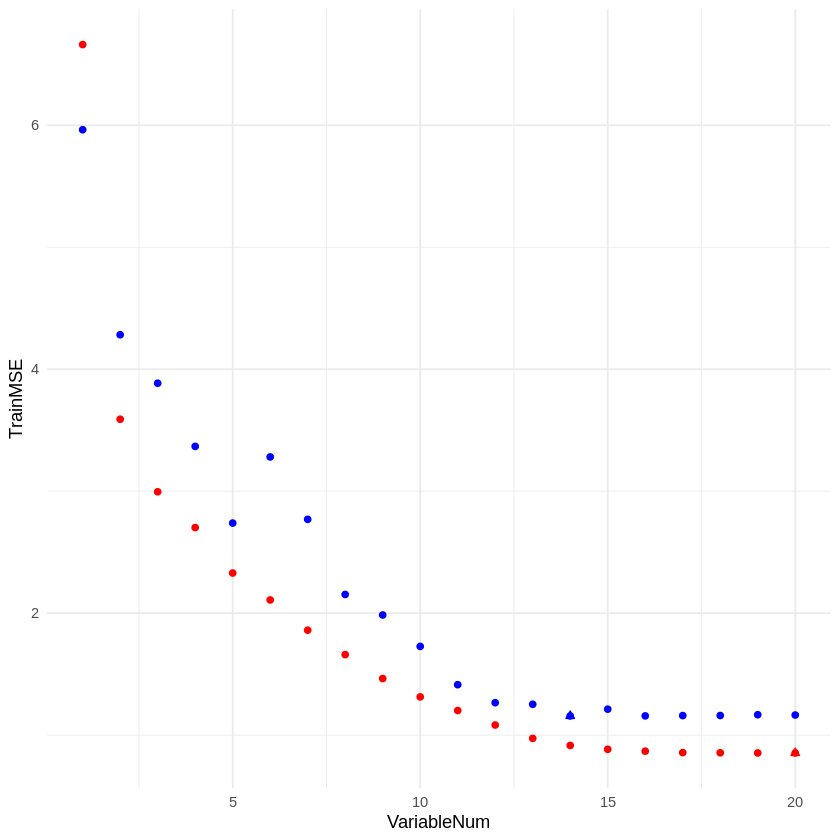

In [47]:
# WRITE YOUR CODE HERE
regfit.train <- regsubsets(y ~ ., data = train.dat, nvmax = 20)
train.errors <- rep(NA, 20)
test.errors <- rep(NA, 20)

predict.regsubsets <- function(object, newdata, id, ...) {
  form <- as.formula(object$call[[2]])
  mat <- model.matrix(form, newdata)
  coefi <- coef(object, id = id)
  xvars <- names(coefi)
  return(mat[, xvars] %*% coefi)
}

for (i in 1:20) {
  pred_train <- predict.regsubsets(regfit.train, newdata = train.dat, id = i)
  train.errors[i] <- mean((train.dat$y - pred_train)^2)

  pred_test <- predict.regsubsets(regfit.train, newdata = test.dat, id = i)
  test.errors[i] <- mean((test.dat$y - pred_test)^2)
}
#had to ask AI for some of this stuff

err.dat <- data.frame(VariableNum = 1:20, TrainMSE=train.errors, TestMSE=test.errors)

train.besty <- which.min(err.dat$TrainMSE)
test.besty <- which.min(err.dat$TestMSE)
train.best <- err.dat[train.besty, ]
test.best <- err.dat[test.besty, ]

ggplot(err.dat, aes(x = VariableNum)) +
  geom_point(aes(y=TrainMSE), color = 'red') +
  geom_point(aes(y=TestMSE), color = 'blue') +
  geom_point(data = train.best, aes(y = TrainMSE), color = 'red', shape = 2) +
  geom_point(data = test.best, aes(y = TestMSE), color = 'blue', shape = 2) +
  theme_minimal()

c) Identify the best model according to the test MSE. How does this model compare to the actual model used to simulate the dataset?

*Note: If the model identified contains only an intercept or all of the features, then generate a new dataset (i.e. repeat part a with a different random seed) until the test set MSE is minimized for an intermediate model size.*

In [ ]:
# WRITE YOUR CODE HERE



> *Test MSE determined the best model contains 14 features, but my actual model contains only 10 features that weren't equal to zero, so the test model overfit (like models in previous questions).*
>

**DUE:** 11:59pm EST, April 2, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *No but I used AI to assist writing the pred_train function*